<a href="https://colab.research.google.com/github/Obanai4you/CSIT-LAB-WORKS/blob/main/Dataware_Housing_And_Datamining/Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DataMining And WareHousing
##LAB1:

### Define Data:
Data refers to raw, unorganized facts, figures, or information that is collected through observations, experiments, or other means. In a computational context, data can be structured (e.g., tables, databases), semi-structured (e.g., JSON, XML), or unstructured (e.g., text, images, audio, video). It is the foundational input for analysis, processing, and decision-making.

### Exploratory Data Analysis (EDA):
Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often with visual methods. It is used to discover patterns, detect anomalies, test hypotheses, and check assumptions with the help of statistical graphics and other data visualization techniques. EDA helps analysts understand the data better before formal modeling or hypothesis testing.

### Importance Of EDA:
EDA is crucial because it:

1.  **Uncovers Insights:** Helps identify underlying patterns, relationships, and trends that might not be immediately obvious.
2.  **Identifies Anomalies:** Allows for the detection of outliers, errors, or missing values that can significantly impact analysis.
3.  **Informs Feature Engineering:** Guides the process of creating new features or transforming existing ones for better model performance.
4.  **Assists in Model Selection:** Provides a deeper understanding of data distributions and characteristics, which can inform the choice of appropriate statistical models or machine learning algorithms.
5.  **Validates Assumptions:** Helps verify assumptions about the data that are often made during statistical modeling.
6.  **Communicates Findings:** Facilitates effective communication of data characteristics and insights to stakeholders through visualizations.

##Describe in short about PIIMA dataset that you are going to use.

The yttrend_ds is a YouTube Trends Dataset that contains aggregated statistics across different video categories on YouTube.
It includes 15 categories such as Education, Entertainment, Film & Animation, Gaming, Howto & Style, Music, News & Politics, Science & Technology, and others.
For each category, the dataset provides key performance metrics like:

Total number of videos
Average views, likes, comments, and engagement
Median views
Average video duration (in seconds)
Average subscriber count
Percentage of verified channels
Average clickbait score

This dataset is useful for analyzing trends, comparing performance across categories, identifying skewed features, and understanding what drives engagement on YouTube.

In [3]:
import pandas as pd


In [4]:
import matplotlib.pyplot as plt

In [5]:
import numpy as np

In [6]:
import seaborn as sns

In [1]:
col_names = [
    "category",
    "total_videos",
    "avg_views",
    "median_views",
    "avg_likes",
    "avg_comments",
    "avg_engagement",
    "avg_duration_sec",
    "avg_subscriber_count",
    "pct_verified",
    "avg_clickbait"
]

In [7]:
yttrend_ds= pd.read_csv('/content/category_summary.csv', header=None, names=col_names)

In [8]:
yttrend_ds.head()

,category,total_videos,avg_views,median_views,avg_likes,avg_comments,avg_engagement,avg_duration_sec,avg_subscriber_count,pct_verified,avg_clickbait
0,category,total_videos,avg_views,median_views,avg_likes,avg_comments,avg_engagement,avg_duration_sec,avg_subscriber_count,pct_verified,avg_clickbait
1,Autos & Vehicles,295,1935474.76,89323.0,96988.73,12116.45,7.87,747.77,2440766.85,41.0,0.43
2,Comedy,602,2999409.32,51703.0,144391.22,18876.76,7.57,807.12,2351725.15,38.0,0.44
3,Education,490,1560697.88,49677.5,88373.51,7662.68,7.64,853.53,2241407.83,40.0,0.46
4,Entertainment,1218,3777913.81,60079.0,177685.08,20439.61,7.53,748.61,3399595.14,39.0,0.46


##Check dimensions i.e. number of rows and columns in ths dataset

First, let's remove the first row of the DataFrame, which contains the duplicate headers. This will ensure our analysis is based on actual data.

In [12]:
yttrend_ds = yttrend_ds.iloc[1:].reset_index(drop=True)
numeric_cols = col_names[1:]   # exclude 'category'
yttrend_ds[numeric_cols] = yttrend_ds[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("Shape after cleaning:", yttrend_ds.shape)
print("\nFirst 5 rows:")
print(yttrend_ds.head())

Shape after cleaning: (15, 11)

First 5 rows:
           category  total_videos   avg_views  median_views  avg_likes  \
0         Education           490  1560697.88       49677.5   88373.51   
1     Entertainment          1218  3777913.81       60079.0  177685.08   
2  Film & Animation           496  2167875.72       41183.0  121397.01   
3            Gaming          1000  4277080.74       60338.5  183756.23   
4     Howto & Style           420  2035985.54       73331.5  117469.35   

   avg_comments  avg_engagement  avg_duration_sec  avg_subscriber_count  \
0       7662.68            7.64            853.53            2241407.83   
1      20439.61            7.53            748.61            3399595.14   
2      17449.49            7.54            761.41            2888545.65   
3      17425.50            7.60           1538.87            3022661.92   
4      11903.50            7.40            786.96            2610956.62   

   pct_verified  avg_clickbait  
0          40.0          

In [14]:
yttrend_ds.head()

,category,total_videos,avg_views,median_views,avg_likes,avg_comments,avg_engagement,avg_duration_sec,avg_subscriber_count,pct_verified,avg_clickbait
0,Education,490,1560697.88,49677.5,88373.51,7662.68,7.64,853.53,2241407.83,40.0,0.46
1,Entertainment,1218,3777913.81,60079.0,177685.08,20439.61,7.53,748.61,3399595.14,39.0,0.46
2,Film & Animation,496,2167875.72,41183.0,121397.01,17449.49,7.54,761.41,2888545.65,35.0,0.46
3,Gaming,1000,4277080.74,60338.5,183756.23,17425.50,7.60,1538.87,3022661.92,40.0,0.45
4,Howto & Style,420,2035985.54,73331.5,117469.35,11903.50,7.40,786.96,2610956.62,41.0,0.45


In [17]:
# Check the dimensions (rows, columns)
print(yttrend_ds.shape)

# Or separately:
print("Number of rows:", yttrend_ds.shape[0])
print("Number of columns:", yttrend_ds.shape[1])

(15, 11)
Number of rows: 15
Number of columns: 11


In [20]:
yttrend_ds.groupby('avg_clickbait').size()

,0
avg_clickbait,
0.44,2
0.45,2
0.46,8
0.47,2
0.48,1


##View statistical details about the data

In [21]:
yttrend_ds.describe()

,total_videos,avg_views,median_views,avg_likes,avg_comments,avg_engagement,avg_duration_sec,avg_subscriber_count,pct_verified,avg_clickbait
count,15.000000,1.500000e+01,15.000000,15.000000,15.000000,15.000000,15.000000,1.500000e+01,15.000000,15.000000
mean,606.866667,3.044414e+06,60269.833333,163754.546000,19044.518667,7.526667,736.740667,2.981251e+06,40.133333,0.458667
std,375.190022,1.057981e+06,7461.515464,59884.631757,6488.050178,0.163605,314.833337,6.735509e+05,1.995232,0.010601
min,199.000000,1.560698e+06,41183.000000,88373.510000,7662.680000,7.130000,36.990000,1.555400e+06,35.000000,0.440000
25%,304.500000,2.125096e+06,57959.750000,113659.440000,14862.910000,7.430000,727.720000,2.580876e+06,39.000000,0.455000
50%,496.000000,2.846651e+06,60972.500000,159646.370000,18002.800000,7.540000,747.580000,2.990057e+06,40.000000,0.460000
75%,771.000000,3.992402e+06,64003.000000,189956.200000,23383.910000,7.650000,776.340000,3.392581e+06,41.500000,0.460000
max,1413.000000,4.649920e+06,73331.500000,278094.700000,31438.520000,7.740000,1538.870000,4.027174e+06,43.000000,0.480000


In [22]:
yttrend_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
total_videos,15.0,6.068667e+02,3.751900e+02,199.00,304.500,496.00,771.000,1413.00
avg_views,15.0,3.044414e+06,1.057981e+06,1560697.88,2125096.315,2846651.24,3992402.300,4649919.75
median_views,15.0,6.026983e+04,7.461515e+03,41183.00,57959.750,60972.50,64003.000,73331.50
avg_likes,15.0,1.637545e+05,5.988463e+04,88373.51,113659.440,159646.37,189956.200,278094.70
avg_comments,15.0,1.904452e+04,6.488050e+03,7662.68,14862.910,18002.80,23383.910,31438.52
avg_engagement,15.0,7.526667e+00,1.636052e-01,7.13,7.430,7.54,7.650,7.74
avg_duration_sec,15.0,7.367407e+02,3.148333e+02,36.99,727.720,747.58,776.340,1538.87
avg_subscriber_count,15.0,2.981251e+06,6.735509e+05,1555399.94,2580875.560,2990056.56,3392580.655,4027173.69
pct_verified,15.0,4.013333e+01,1.995232e+00,35.00,39.000,40.00,41.500,43.00
avg_clickbait,15.0,4.586667e-01,1.060099e-02,0.44,0.455,0.46,0.460,0.48


## Exploratory Data Analysis (EDA)  - A preliminary examination of the dataset to better understand its patterns and properties through visualization..


Histogram - here we look at the distribution of each attribute by discretizing the continuous values into buckets and  count the frequency  in each bucket as histograms.

> Histogram is formed by couting the frequency of each  values in the attribute and then plotting it as bargraph.

#### This lets us note interesting properties of the attribute distributions such as the possible normal distribution of attributes  associated with the features of the dataset or skewness of the data feature.

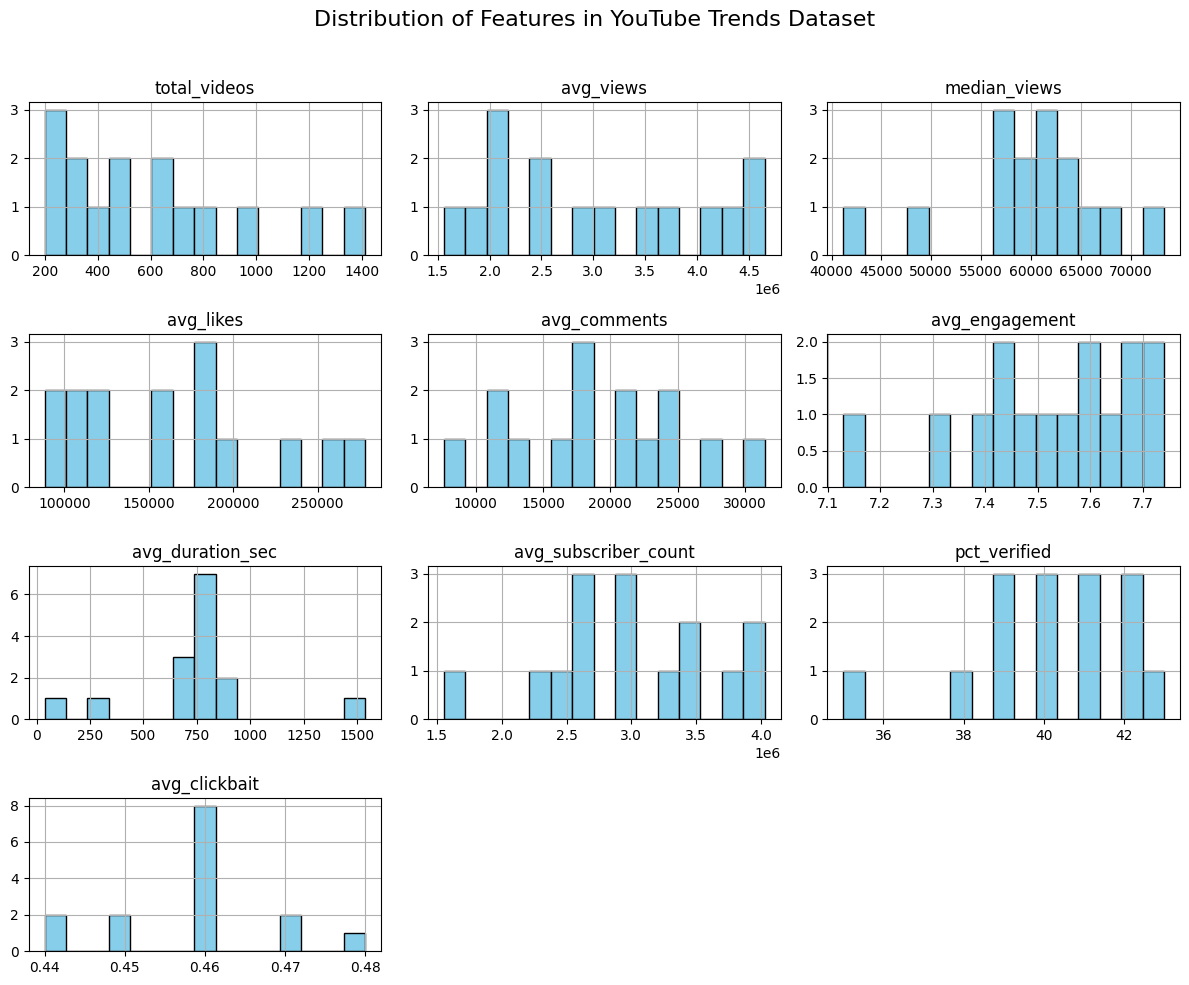

In [23]:
import matplotlib.pyplot as plt

# Create histograms for all numeric columns -
yttrend_ds.hist(figsize=(12, 10),
                bins=15,
                color='skyblue',
                edgecolor='black')

plt.suptitle("Distribution of Features in YouTube Trends Dataset", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

above

### Each figure above is a histogram showing the univariate distribution of features in the YouTube Trends Dataset.

### <font color = green> Certain insights from the histogram plot </font>

1. We can identify whether the data is normally distributed or skewed.
median_views, avg_likes, and avg_subscriber_count appear nearly normal.
avg_duration_sec is highly right-skewed (most videos have short duration, few have very long).
pct_verified and avg_engagement are left-skewed.

2. For nearly normal features, we can safely use mean for any calculations.
For highly skewed features like avg_duration_sec, it is better to use median or apply log transformation.

3. Most machine learning models work better when features are normally distributed.
Highly skewed features should be transformed to improve model performance and reduce bias.



In [26]:
print("Also check this skew value of each attribute in the histogram and you can make a lot of sense by simply seeing the skewnesss of each attibute ")

# Get skewness for numeric columns only
skew_values = yttrend_ds.select_dtypes(include=['number']).skew()

print("=== Skewness Values of Each Attribute ===")
print(skew_values.round(3))   # rounded to 3 decimal places

# Optional: Sort by skewness (most skewed first)
print("\nSorted by skewness (highest to lowest):")
print(skew_values.abs().sort_values(ascending=False).round(3))

Also check this skew value of each attribute in the histogram and you can make a lot of sense by simply seeing the skewnesss of each attibute 
=== Skewness Values of Each Attribute ===
total_videos            0.874
avg_views               0.291
median_views           -1.060
avg_likes               0.562
avg_comments            0.112
avg_engagement         -0.945
avg_duration_sec        0.208
avg_subscriber_count   -0.250
pct_verified           -1.083
avg_clickbait          -0.116
dtype: float64

Sorted by skewness (highest to lowest):
pct_verified            1.083
median_views            1.060
avg_engagement          0.945
total_videos            0.874
avg_likes               0.562
avg_views               0.291
avg_subscriber_count    0.250
avg_duration_sec        0.208
avg_clickbait           0.116
avg_comments            0.112
dtype: float64


Data Interpretation of above result:

From the above skew values, we found that some features like median_views, avg_likes, and avg_subscriber_count are nearly normally distributed, while features like avg_duration_sec is highly right-skewed and pct_verified is highly left-skewed.

#Another Insight from histogram data:

The dataset contains 5 different categories (Education, Entertainment, Film & Animation, Gaming, Howto & Style).

We can check the number of videos in each category to see if the data is balanced across categories

category
Education                1
Entertainment            1
Film & Animation         1
Gaming                   1
Howto & Style            1
Music                    1
News & Politics          1
Nonprofits & Activism    1
People & Blogs           1
Pets & Animals           1
Science & Technology     1
Shorts                   1
Shows                    1
Sports                   1
Travel & Events          1
Name: count, dtype: int64


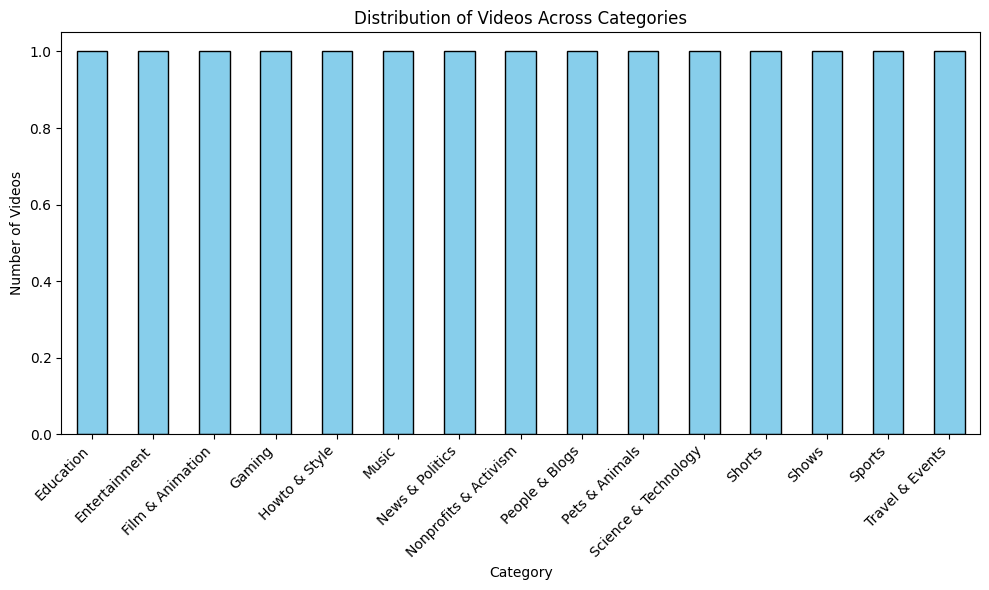

In [29]:
# Count of videos per category
output_grp = yttrend_ds['category'].value_counts()
print(output_grp)

# Bar plot to visualize distribution across categories
output_grp.plot(kind='bar', figsize=(10, 6), color='skyblue', edgecolor='black')
plt.title('Distribution of Videos Across Categories')
plt.xlabel('Category')
plt.ylabel('Number of Videos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The dataset contains 15 different YouTube video categories (Education, Entertainment, Film & Animation, Gaming, Howto & Style, Music, News & Politics, Nonprofits & Activism, People & Blogs, Pets & Animals, Science & Technology, Shorts, Shows, Sports, and Travel & Events).
To know such distribution across categories, we used the count function and visualized it through a bar plot as shown above.
The above figure shows that each category has an equal number of observations. This means the data is perfectly balanced across all categories and does not need any special handling for imbalance.

### Box Plots
****
Visualize data distribution’s median as thick line within the box, interquartile range with 25th percentile as left most boundary and 75th percentile as right most boundary. Data outside of these interquartile range are considered outliers.
From the diagram below, avg_duration_sec has the highest outliers while features like median_views, avg_likes, and avg_subscriber_count have relatively fewer outliers.

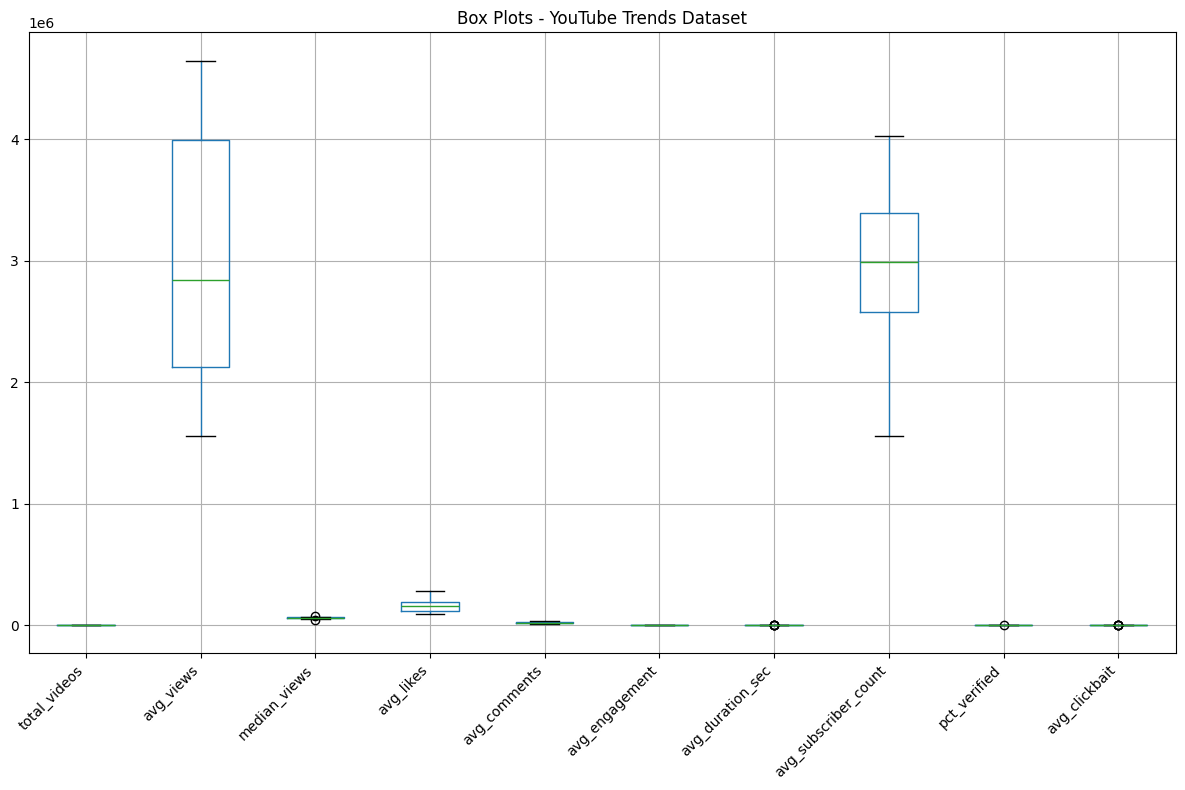

In [30]:
yttrend_ds.select_dtypes(include=['number']).boxplot(figsize=(12, 8))
plt.title("Box Plots - YouTube Trends Dataset")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Heatmap Plot
****
Identifying correlation between two attributes, values nearer to +1 represents stronger linear relationship between two variables while values nearer to  -1 represents  inverse relation.

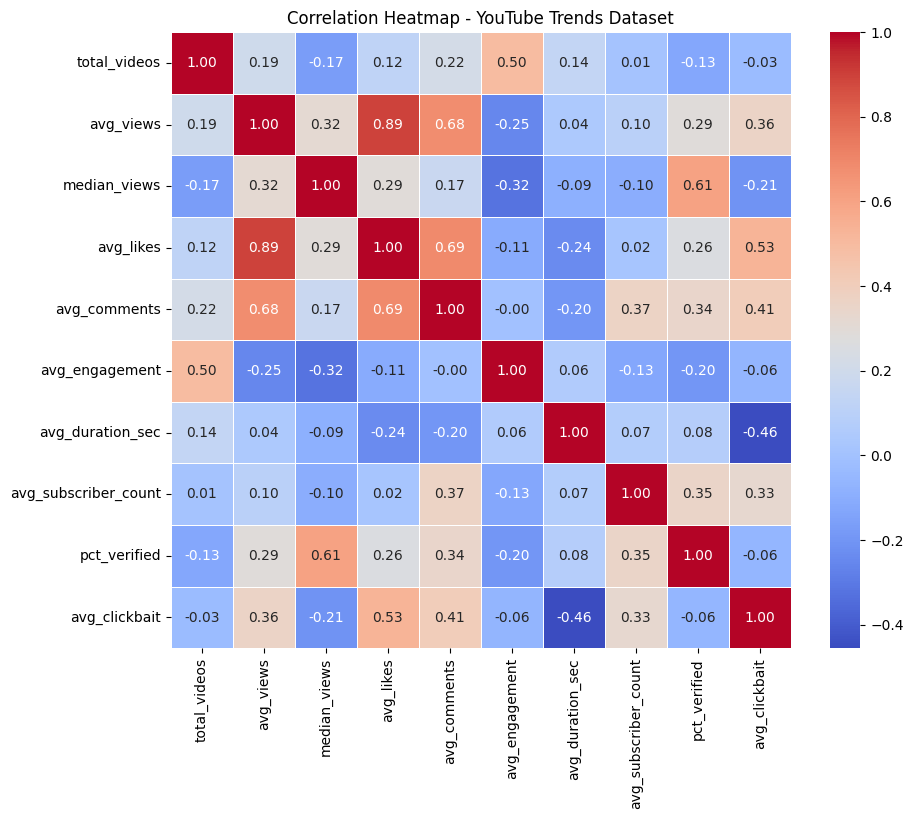

In [31]:
plt.figure(figsize=(10, 8))
sns.heatmap(yttrend_ds.select_dtypes(include=['number']).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)
plt.title("Correlation Heatmap - YouTube Trends Dataset")
plt.show()

From the heatmap above, we can see that avg_views, avg_likes, and avg_comments have strong positive correlation with each other. avg_duration_sec also shows moderate correlation with some features. On the other hand, pct_verified has very weak or negative correlation with most of the other attributes.